# Clasificación de Perros y Gatos usando PyTorch

En este notebook implementaremos un clasificador de imágenes para distinguir entre perros y gatos utilizando **PyTorch** y redes neuronales convolucionales (CNN).

## Contenido
- Importación de librerías y carga de datos
- Exploración del dataset
- Transformación y preparación de datos
- Construcción del modelo CNN
- Entrenamiento del modelo
- Evaluación y visualización de resultados

## 1. Importación de librerías

In [3]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import kagglehub

# Verificar si CUDA está disponible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


## 2. Descarga del dataset de Kaggle

In [4]:
# Descargar dataset de Kaggle
path = kagglehub.dataset_download("moazeldsokyx/dogs-vs-cats")
print("Path to dataset files:", path)

# Definir rutas del dataset
data_dir = os.path.join(path, "dataset")
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "validation")
test_dir = os.path.join(data_dir, "test")

Path to dataset files: /home/edwin/.cache/kagglehub/datasets/moazeldsokyx/dogs-vs-cats/versions/1


## 3. Exploración del dataset

Verificamos la cantidad de imágenes en cada conjunto (train, validation, test).

In [5]:
# Contar imágenes por categoría
train_cats = len(os.listdir(os.path.join(train_dir, "cats")))
train_dogs = len(os.listdir(os.path.join(train_dir, "dogs")))
val_cats = len(os.listdir(os.path.join(val_dir, "cats")))
val_dogs = len(os.listdir(os.path.join(val_dir, "dogs")))
test_cats = len(os.listdir(os.path.join(test_dir, "cats")))
test_dogs = len(os.listdir(os.path.join(test_dir, "dogs")))

print(f"Training - Cats: {train_cats}, Dogs: {train_dogs}, Total: {train_cats + train_dogs}")
print(f"Validation - Cats: {val_cats}, Dogs: {val_dogs}, Total: {val_cats + val_dogs}")
print(f"Test - Cats: {test_cats}, Dogs: {test_dogs}, Total: {test_cats + test_dogs}")

Training - Cats: 10000, Dogs: 10000, Total: 20000
Validation - Cats: 2500, Dogs: 2500, Total: 5000
Test - Cats: 6242, Dogs: 6219, Total: 12461


## 4. Transformaciones y carga de datos

Definimos las transformaciones para normalizar y aumentar los datos. PyTorch utiliza `transforms` para preprocesar las imágenes.

In [6]:
# Transformaciones para el dataset
data_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Cargar datasets usando ImageFolder
train_dataset = datasets.ImageFolder(train_dir, transform=data_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=data_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=data_transform)

# Crear DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Nombres de las clases
class_names = train_dataset.classes
print(f"Clases: {class_names}")

Clases: ['cats', 'dogs']


## 5. Visualización de imágenes de ejemplo

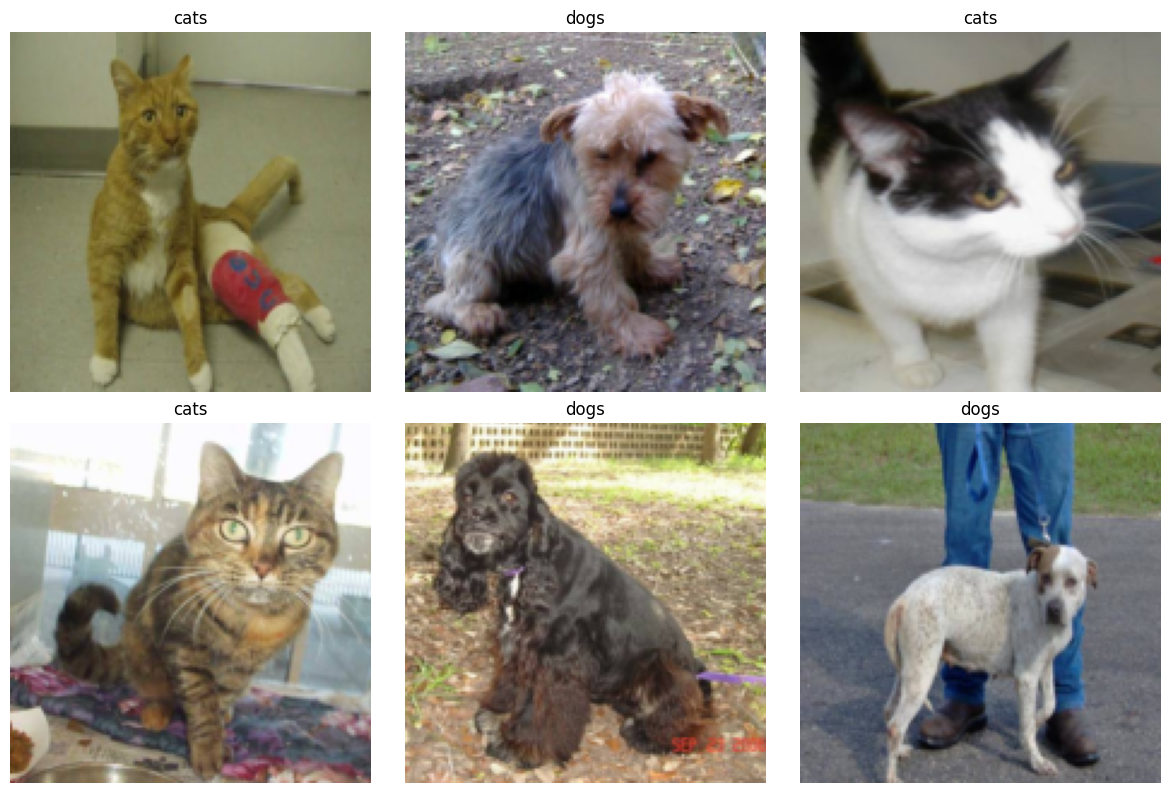

In [7]:
def plot_images(dataloader, n_images=6):
    """Muestra imágenes del dataloader"""
    images, labels = next(iter(dataloader))
    
    plt.figure(figsize=(12, 8))
    for i in range(min(n_images, len(images))):
        plt.subplot(2, 3, i + 1)
        # Desnormalizar la imagen
        img = images[i].numpy().transpose((1, 2, 0))
        img = img * 0.5 + 0.5  # Revertir la normalización
        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Mostrar imágenes de entrenamiento
plot_images(train_loader)

## 6. Definición del modelo CNN

Creamos una red neuronal convolucional (CNN) utilizando `nn.Module` de PyTorch. El modelo incluye:
- Capas convolucionales para extraer características
- Capas de pooling para reducir dimensionalidad
- Capas fully connected para la clasificación

In [8]:
class CatDogCNN(nn.Module):
    def __init__(self):
        super(CatDogCNN, self).__init__()
        
        # Bloque convolucional 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Bloque convolucional 2
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Bloque convolucional 3
        self.conv5 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        
        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Capas fully connected
        self.fc1 = nn.Linear(256, 1024)
        self.fc2 = nn.Linear(1024, 2)
        
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        # Bloque 1
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        
        # Bloque 2
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)
        
        # Bloque 3
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        
        # Global pooling
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Crear el modelo y moverlo al dispositivo
model = CatDogCNN().to(device)
print(model)

CatDogCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=256, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


## 7. Función de pérdida y optimizador

Definimos la función de pérdida (CrossEntropyLoss) y el optimizador (Adam) para entrenar el modelo.

In [9]:
# Definir función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 8. Funciones de entrenamiento y validación

In [10]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Entrena el modelo por una época"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Estadísticas
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    """Valida el modelo"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

## 9. Entrenamiento del modelo

Entrenamos el modelo durante varias épocas y monitoreamos el desempeño en train y validación.

In [11]:
# Entrenar el modelo
num_epochs = 10

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print("-" * 50)

Epoch 1/10
  Train Loss: 0.6571, Train Acc: 0.5937
  Val Loss: 0.6742, Val Acc: 0.5836
--------------------------------------------------
Epoch 2/10
  Train Loss: 0.6048, Train Acc: 0.6700
  Val Loss: 0.6034, Val Acc: 0.6632
--------------------------------------------------
Epoch 3/10
  Train Loss: 0.5556, Train Acc: 0.7193
  Val Loss: 0.5517, Val Acc: 0.7228
--------------------------------------------------
Epoch 4/10
  Train Loss: 0.5225, Train Acc: 0.7450
  Val Loss: 0.5135, Val Acc: 0.7528
--------------------------------------------------
Epoch 5/10
  Train Loss: 0.4848, Train Acc: 0.7738
  Val Loss: 0.5263, Val Acc: 0.7410
--------------------------------------------------
Epoch 6/10
  Train Loss: 0.4290, Train Acc: 0.8052
  Val Loss: 0.4074, Val Acc: 0.8232
--------------------------------------------------
Epoch 7/10
  Train Loss: 0.3622, Train Acc: 0.8394
  Val Loss: 0.3421, Val Acc: 0.8554
--------------------------------------------------
Epoch 8/10
  Train Loss: 0.3167, T

## 10. Evaluación en el conjunto de test

In [12]:
# Evaluar en el conjunto de test
test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Test Loss: 0.3273, Test Accuracy: 0.8537


## 11. Visualización de predicciones

Mostramos algunas predicciones del modelo. En verde las correctas, en rojo las incorrectas.

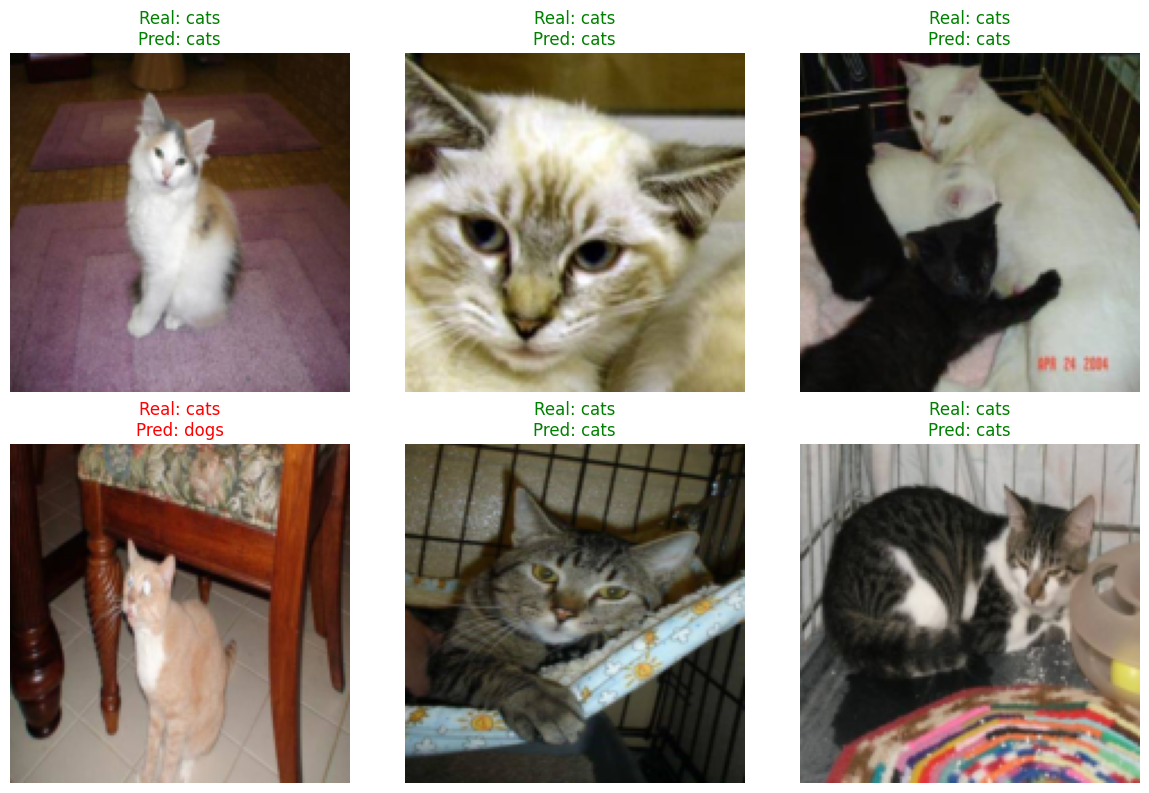

In [13]:
def plot_predictions(model, dataloader, device, n_images=6):
    """Muestra predicciones del modelo"""
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
    
    images = images.cpu()
    labels = labels.cpu()
    predictions = predictions.cpu()
    
    plt.figure(figsize=(12, 8))
    for i in range(min(n_images, len(images))):
        plt.subplot(2, 3, i + 1)
        # Desnormalizar la imagen
        img = images[i].numpy().transpose((1, 2, 0))
        img = img * 0.5 + 0.5
        plt.imshow(img)
        
        # Color verde si es correcto, rojo si es incorrecto
        color = 'green' if predictions[i] == labels[i] else 'red'
        title = f"Real: {class_names[labels[i]]}\nPred: {class_names[predictions[i]]}"
        plt.title(title, color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Mostrar predicciones del conjunto de test
plot_predictions(model, test_loader, device)

## 12. Guardar el modelo

Guardamos el modelo entrenado para poder usarlo más adelante.

In [14]:
# Guardar el modelo
torch.save(model.state_dict(), "catdog_model_pytorch.pth")
print("Modelo guardado exitosamente!")

Modelo guardado exitosamente!
